# 🚗 Toronto Traffic Collision Severity Prediction
## Notebook 4 of 5 — Model Training & Evaluation

**Author:** Nishi Bhavesh Patel | Student ID: 501356244

---
### What this notebook does:
- Loads cleaned dataset from Notebook 2
- Prepares features (X) and target (y)
- Fixes all NaN values
- Splits into Train / Validation / Test sets
- Applies SMOTE to fix class imbalance
- Trains 5 models
- Evaluates and compares all models
- Saves models and test set for Notebook 5

### Input:  `collisions_cleaned.csv`
### Output: `trained_models.pkl`, `X_test.csv`, `y_test.csv`, `model_results.csv`

---

## Step 1 — Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

CLEANED_FILE  = '../MRP - Final Sem/Data/collisions_cleaned.csv'
MODELS_FOLDER = '../MRP - Final Sem/Models/'
PLOTS_FOLDER  = '../MRP - Final Sem/Plots/'
os.makedirs(MODELS_FOLDER, exist_ok=True)
os.makedirs(PLOTS_FOLDER,  exist_ok=True)

RANDOM_STATE    = 42
severity_labels = {0:'Minor', 1:'Major', 2:'Fatal'}
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded!')

Libraries loaded!


---
## Step 2 — Load Data

In [6]:
df = pd.read_csv(CLEANED_FILE, low_memory=False)
print(f'Loaded: {df.shape}')

Loaded: (677056, 48)


---
## Step 3 — Build Feature Matrix X and Target y

In [7]:
DROP_COLS = [
    'severity', 'OCC_DATE', 'datetime',
    'FATALITIES', 'INJURY_COLLISIONS', 'PD_COLLISIONS', 'FTR_COLLISIONS',
    'NEIGHBOURHOOD_158', 'DIVISION', 'weather_desc', 'geometry',
    '_id', 'OBJECTID', 'INDEX_', 'x', 'y'
]
drop_cols    = [c for c in DROP_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['severity'].copy()

print(f'Features: {X.shape[1]} columns')
print(f'Rows:     {X.shape[0]:,}')
print(f'NaN before fix: {X.isnull().sum().sum():,}')

Features: 37 columns
Rows:     677,056
NaN before fix: 0


---
## Step 4 — Fix All NaN Values

This step MUST run before the train/test split and before SMOTE.

In [8]:
# Show which columns have NaN
nan_report = X.isnull().sum()
nan_cols   = nan_report[nan_report > 0].sort_values(ascending=False)
print(f'Columns with NaN: {len(nan_cols)}')
if len(nan_cols) > 0:
    print(nan_cols.to_string())

Columns with NaN: 0


In [26]:
# A: Convert object/bool columns to numeric codes
for col in X.select_dtypes(include=['object','bool']).columns:
    X[col] = pd.Categorical(X[col]).codes

# B: Drop columns where ALL values are NaN
all_nan = [c for c in X.columns if X[c].isnull().all()]
if all_nan:
    print(f'Dropping fully-empty columns: {all_nan}')
    X = X.drop(columns=all_nan)

# C: Drop columns where more than 80% are NaN
mostly_nan = [c for c in X.columns if X[c].isnull().mean() > 0.8]
if mostly_nan:
    print(f'Dropping >80% NaN columns: {mostly_nan}')
    X = X.drop(columns=mostly_nan)

# D: Fill remaining NaN with median (0 if median itself is NaN)
for col in X.columns:
    if X[col].isnull().any():
        med = X[col].median()
        X[col] = X[col].fillna(med if pd.notna(med) else 0)

# E: Last resort — drop any remaining NaN rows
if X.isnull().sum().sum() > 0:
    mask = X.isnull().any(axis=1)
    before = len(X)
    X = X[~mask]
    y = y[~mask]
    print(f'Dropped {before - len(X)} rows with remaining NaN')

final_nan = X.isnull().sum().sum()
print(f'\nNaN remaining: {final_nan}')
print('✅ Ready for SMOTE!' if final_nan == 0 else '❌ Still has NaN!')
print(f'Shape: {X.shape}')
print(f'\nClass distribution:')
for k, v in y.value_counts().sort_index().items():
    print(f'  {severity_labels[k]:8s}: {v:,} ({v/len(y)*100:.1f}%)')


NaN remaining: 0
✅ Ready for SMOTE!
Shape: (677056, 37)

Class distribution:
  Minor   : 580,492 (85.7%)
  Major   : 95,928 (14.2%)
  Fatal   : 636 (0.1%)


---
## Step 5 — Train / Validation / Test Split

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train:      {len(X_train):,}')
print(f'Validation: {len(X_val):,}')
print(f'Test:       {len(X_test):,}')
print(f'NaN in train: {X_train.isnull().sum().sum()}  ✓')

X_test.to_csv(f'{MODELS_FOLDER}X_test.csv', index=False)
y_test.to_csv(f'{MODELS_FOLDER}y_test.csv', index=False)
print('Test set saved for Notebook 5')

Train:      473,939
Validation: 101,558
Test:       101,559
NaN in train: 0  ✓
Test set saved for Notebook 5


---
## Step 6 — Apply SMOTE

In [11]:
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('After SMOTE — training class distribution:')
for u, c in zip(*np.unique(y_train_sm, return_counts=True)):
    print(f'  {severity_labels[u]:8s}: {c:,}')
print(f'Total training rows: {len(X_train_sm):,}')

After SMOTE — training class distribution:
  Minor   : 406,344
  Major   : 406,344
  Fatal   : 406,344
Total training rows: 1,219,032


---
## Step 7 — Train All 5 Models

In [12]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE, multi_class='ovr'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(128,64,32), max_iter=300,
        early_stopping=True, random_state=RANDOM_STATE)
}

trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    t = time.time()
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f'Done ({time.time()-t:.1f}s)')

with open(f'{MODELS_FOLDER}trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)
print(f'\nAll models saved!')

Training Logistic Regression... Done (571.8s)
Training Random Forest... Done (232.7s)
Training XGBoost... Done (80.8s)
Training Gradient Boosting... Done (6687.4s)
Training Neural Network... Done (78956.9s)

All models saved!


---
## Step 8 — Evaluate All Models

In [13]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    try:
        auc = roc_auc_score(y_test, model.predict_proba(X_test),
                            multi_class='ovr', average='weighted')
    except: auc = None
    results.append({
        'Model':       name,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':    round(f1_score(y_test, y_pred, average='macro'), 4),
        'ROC-AUC':     round(auc, 4) if auc else 'N/A'
    })

results_df = pd.DataFrame(results).sort_values('F1 Weighted', ascending=False)
results_df.to_csv(f'{MODELS_FOLDER}model_results.csv', index=False)
print('Model Comparison (Test Set):')
results_df

Model Comparison (Test Set):


,Model,Accuracy,F1 Weighted,F1 Macro,ROC-AUC
2,XGBoost,0.9002,0.8920,0.5193,0.7839
1,Random Forest,0.8972,0.8911,0.5148,0.7809
3,Gradient Boosting,0.8979,0.8904,0.5126,0.7823
4,Neural Network,0.8700,0.8731,0.4973,0.7624
0,Logistic Regression,0.8652,0.8663,0.4765,0.7452


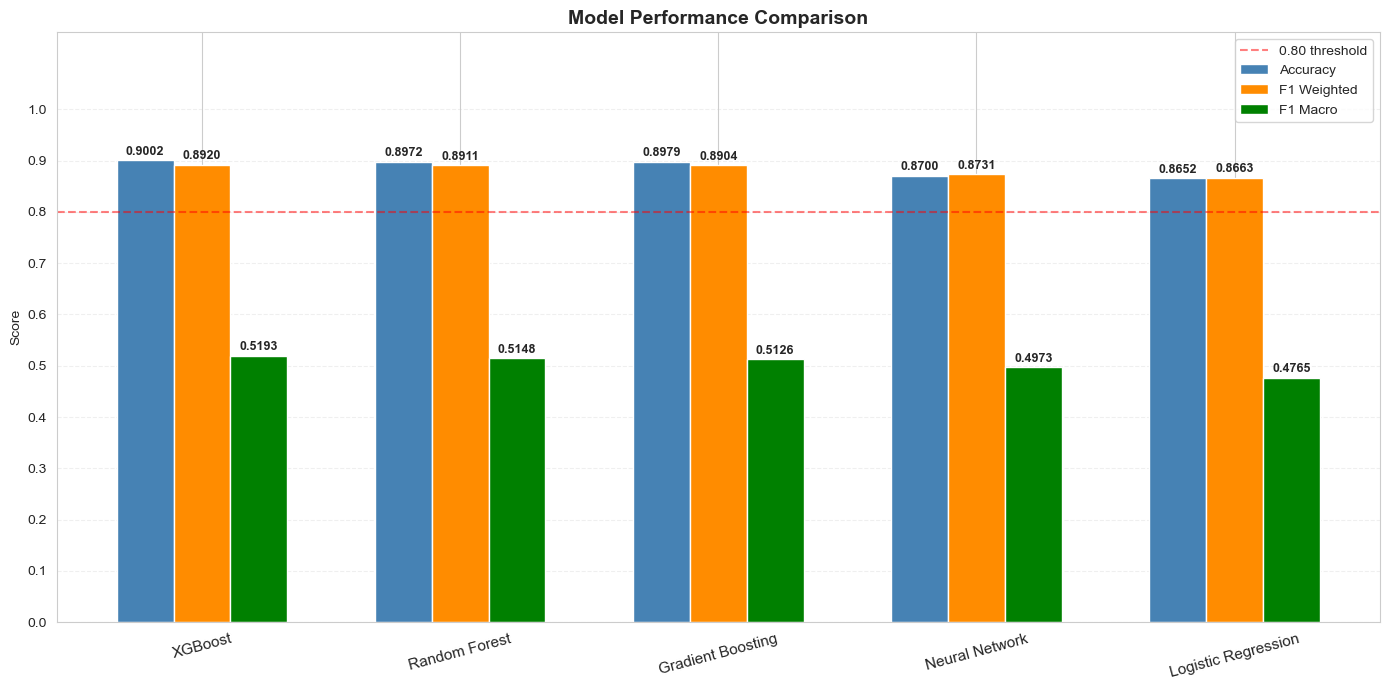

In [14]:
# Comparison bar chart — clean with precise labels
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(results_df))
w = 0.22

bars1 = ax.bar(x-w, results_df['Accuracy'],    w, label='Accuracy',    color='steelblue',  edgecolor='white')
bars2 = ax.bar(x,   results_df['F1 Weighted'], w, label='F1 Weighted', color='darkorange', edgecolor='white')
bars3 = ax.bar(x+w, results_df['F1 Macro'],   w, label='F1 Macro',    color='green',       edgecolor='white')

# Exact value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.4f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, fontsize=11)

# Standard y-axis 0 to 1 with 0.1 steps
ax.set_ylim(0, 1.15)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Best model report
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test)

print(f'Best Model: {best_model_name}')
print('='*55)
print(classification_report(y_test, y_pred_best, target_names=['Minor','Major','Fatal']))

Best Model: XGBoost
              precision    recall  f1-score   support

       Minor       0.92      0.97      0.94     87074
       Major       0.72      0.48      0.58     14389
       Fatal       0.02      0.05      0.03        96

    accuracy                           0.90    101559
   macro avg       0.56      0.50      0.52    101559
weighted avg       0.89      0.90      0.89    101559



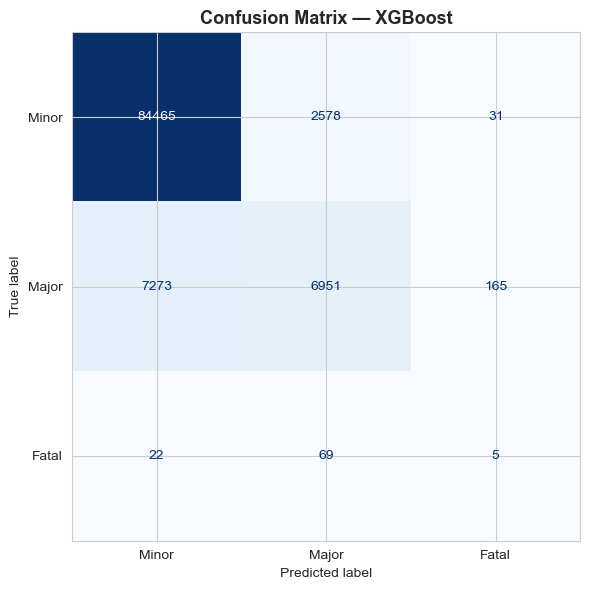

In [16]:
# Confusion matrix — best model
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Minor','Major','Fatal']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_10_confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

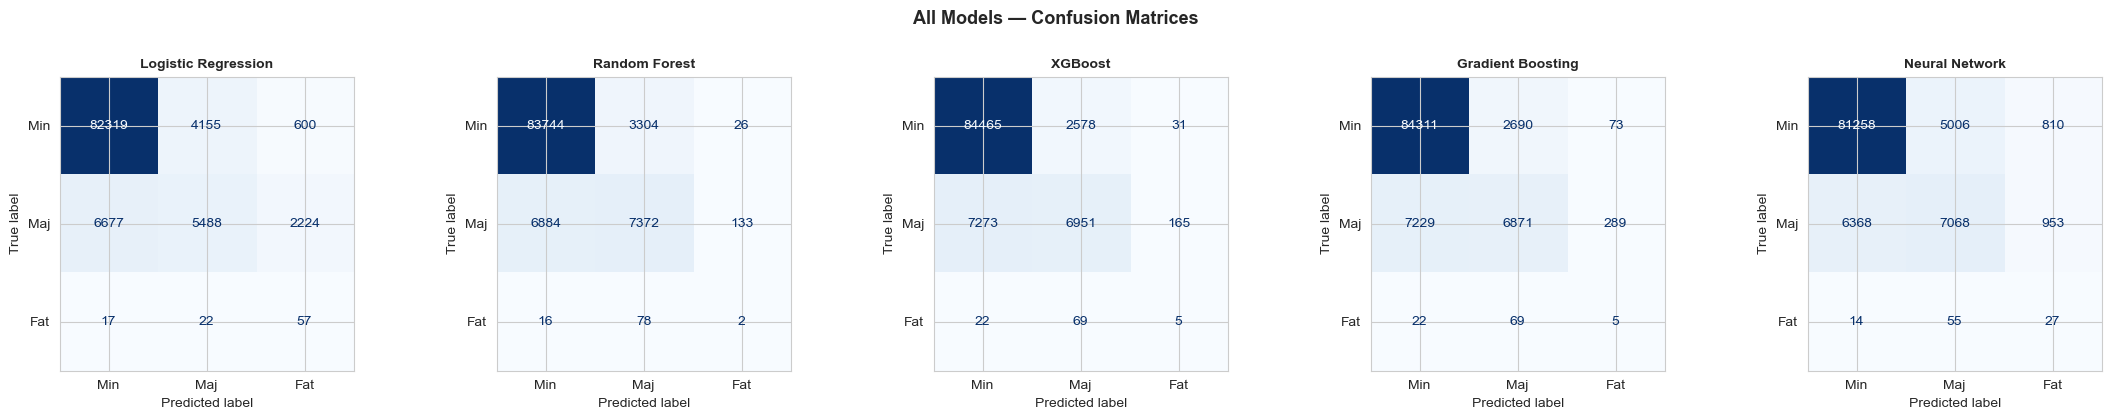

In [17]:
# All 5 confusion matrices
fig, axes = plt.subplots(1,5, figsize=(22,4))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, model.predict(X_test)),
        display_labels=['Min','Maj','Fat']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.suptitle('All Models — Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_11_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Subgroup Analysis

In [18]:
df_test = X_test.copy()
df_test['true_severity'] = y_test.values
df_test['pred_severity'] = y_pred_best

# By Season
season_cols = [c for c in df_test.columns if 'season_' in c]
if season_cols:
    df_test['season_label'] = df_test[season_cols].idxmax(axis=1).str.replace('season_','')
    rows = []
    for s, grp in df_test.groupby('season_label'):
        if len(grp) < 10: continue
        rows.append({'Season':s,
                     'F1': round(f1_score(grp['true_severity'],grp['pred_severity'],average='weighted'),4),
                     'Accuracy': round(accuracy_score(grp['true_severity'],grp['pred_severity']),4),
                     'N': len(grp)})
    print('Performance by Season:')
    print(pd.DataFrame(rows).to_string(index=False))

Performance by Season:
Season     F1  Accuracy     N
  Fall 0.8852    0.8935 26318
Spring 0.8959    0.9038 23496
Summer 0.8856    0.8930 24834
Winter 0.9013    0.9101 26911


In [19]:
# By Time of Day
hour_cols = [c for c in df_test.columns if 'hour_category_' in c]
if hour_cols:
    df_test['hour_label'] = df_test[hour_cols].idxmax(axis=1).str.replace('hour_category_','')
    rows = []
    for h, grp in df_test.groupby('hour_label'):
        if len(grp) < 10: continue
        rows.append({'Time':h,
                     'F1': round(f1_score(grp['true_severity'],grp['pred_severity'],average='weighted'),4),
                     'Accuracy': round(accuracy_score(grp['true_severity'],grp['pred_severity']),4),
                     'N': len(grp)})
    print('Performance by Time of Day:')
    print(pd.DataFrame(rows).to_string(index=False))

Performance by Time of Day:
      Time     F1  Accuracy     N
late_night 0.8917    0.9008 77646
   weekend 0.8928    0.8982 23913


In [20]:
# Fatal recall by time
print('Fatal Recall by Time (% of actual fatals correctly caught):')
if 'hour_label' in df_test.columns:
    for h, grp in df_test.groupby('hour_label'):
        fg = grp[grp['true_severity']==2]
        if len(fg)==0: continue
        recall = (fg['pred_severity']==2).sum()/len(fg)
        print(f'  {h:15s}: {recall*100:.1f}%  (n={len(fg)} fatals)')

Fatal Recall by Time (% of actual fatals correctly caught):
  late_night     : 6.8%  (n=74 fatals)
  weekend        : 0.0%  (n=22 fatals)


In [21]:
# Comparing SMOTE vs ADASYN vs SMOTEENN vs Undersampling vs Class Weights only

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek  # faster than SMOTEENN

balancing_strategies = {
    'No Resampling (Class Weights)': None,
    'SMOTE':                         SMOTE(random_state=RANDOM_STATE),
    'ADASYN':                        ADASYN(random_state=RANDOM_STATE),
    'SMOTETomek':                    SMOTETomek(random_state=RANDOM_STATE),  # replaces SMOTEENN
    'Random Undersampling':          RandomUnderSampler(random_state=RANDOM_STATE),
}

print('Strategies to compare:')
for name in balancing_strategies:
    print(f'  - {name}')

Strategies to compare:
  - No Resampling (Class Weights)
  - SMOTE
  - ADASYN
  - SMOTETomek
  - Random Undersampling


In [22]:
# Train XGBoost with each strategy and record results
strategy_results = []

for strategy_name, sampler in balancing_strategies.items():
    print(f'Testing: {strategy_name}...', end=' ')

    if sampler is None:
        X_res, y_res = X_train.copy(), y_train.copy()
        model = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1, scale_pos_weight=3
        )
    else:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        model = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1
        )

    model.fit(X_res, y_res)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred,
                                   target_names=['Minor','Major','Fatal'],
                                   output_dict=True)

    strategy_results.append({
        'Strategy':     strategy_name,
        'Train Size':   len(X_res),
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':  round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':     round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 Minor':     round(report['Minor']['f1-score'], 4),
        'F1 Major':     round(report['Major']['f1-score'], 4),
        'F1 Fatal':     round(report['Fatal']['f1-score'], 4),
        'Recall Fatal': round(report['Fatal']['recall'], 4),
    })
    print('Done!')

strategy_df = pd.DataFrame(strategy_results).sort_values('F1 Macro', ascending=False)
print('\nBalancing Strategy Comparison:')
strategy_df

Testing: No Resampling (Class Weights)... Done!
Testing: SMOTE... Done!
Testing: ADASYN... Done!
Testing: SMOTETomek... Done!
Testing: Random Undersampling... Done!

Balancing Strategy Comparison:


,Strategy,Train Size,Accuracy,F1 Weighted,F1 Macro,F1 Minor,F1 Major,F1 Fatal,Recall Fatal
1,SMOTE,1219032,0.9002,0.8920,0.5193,0.9446,0.5796,0.0337,0.0521
3,SMOTETomek,1189380,0.9001,0.8918,0.5183,0.9446,0.5781,0.0321,0.0521
2,ADASYN,1232567,0.9001,0.8921,0.5167,0.9446,0.5798,0.0257,0.0417
0,No Resampling (Class Weights),473939,0.9037,0.8941,0.5109,0.9459,0.5869,0.0000,0.0000
4,Random Undersampling,1335,0.7170,0.7656,0.3922,0.8408,0.3155,0.0203,0.6771


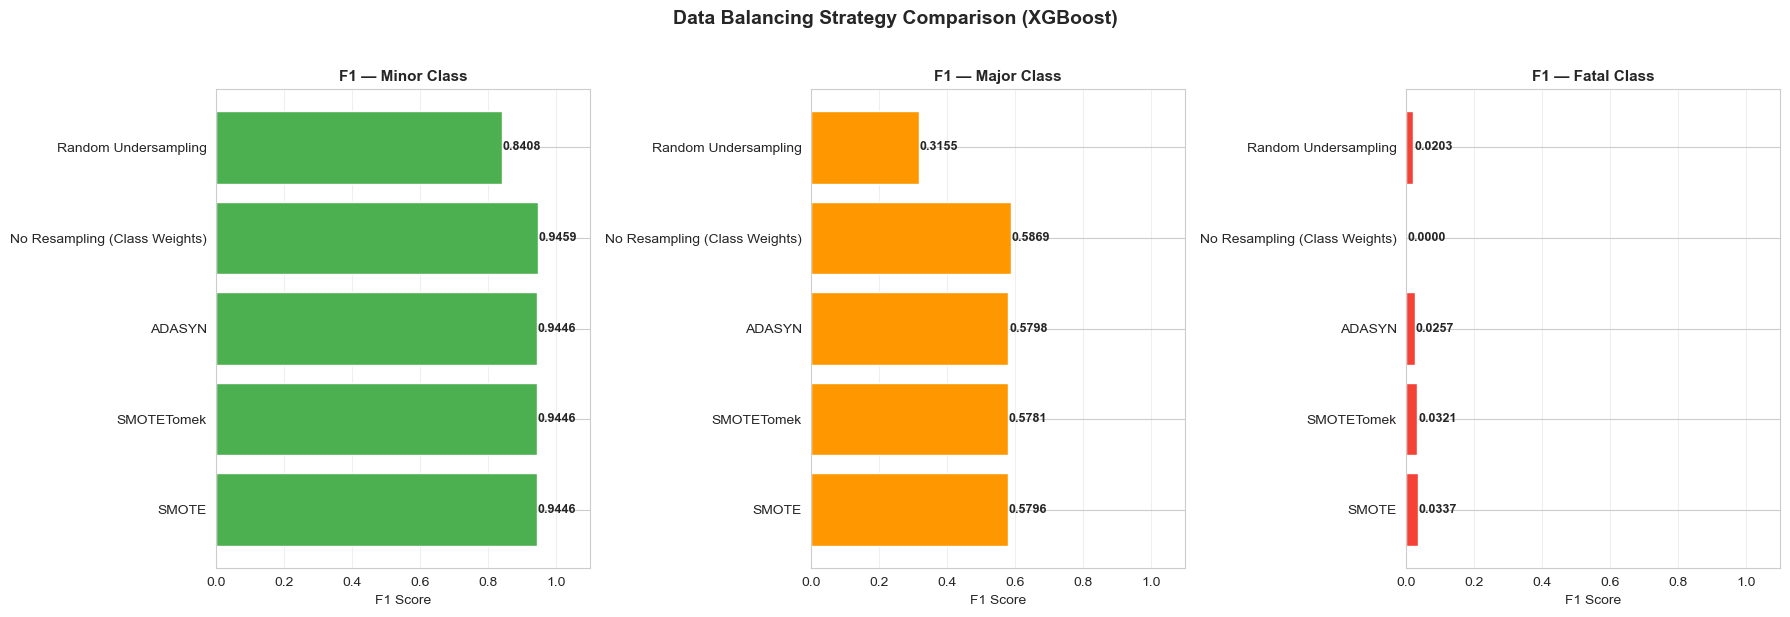

In [23]:
# Plot: F1 per class for each strategy
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['F1 Minor', 'F1 Major', 'F1 Fatal']
colors  = ['#4CAF50', '#FF9800', '#F44336']
titles  = ['F1 — Minor Class', 'F1 — Major Class', 'F1 — Fatal Class']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    bars = ax.barh(strategy_df['Strategy'], strategy_df[metric],
                   color=color, edgecolor='white')
    for bar, val in zip(bars, strategy_df[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('F1 Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Data Balancing Strategy Comparison (XGBoost)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_12_balancing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

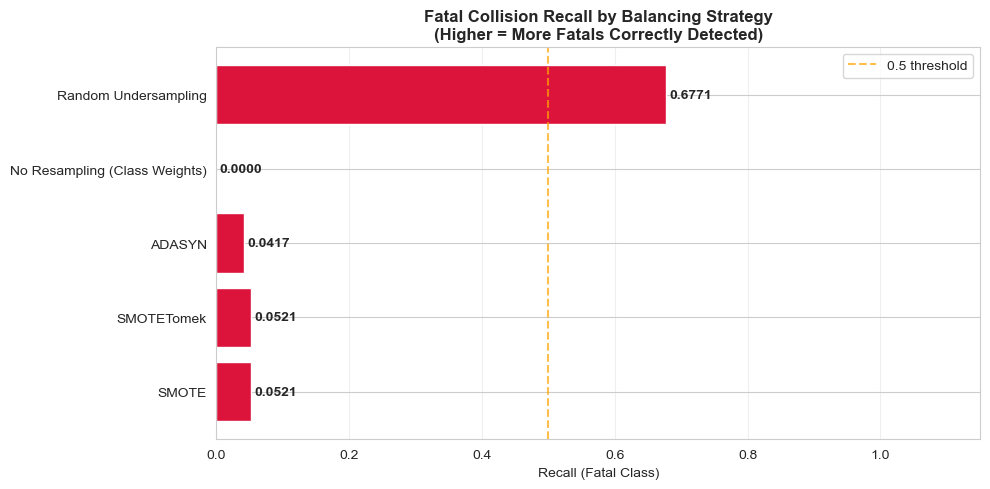


Best strategy for Fatal recall:
  → Random Undersampling

Best overall F1 Macro:
  → SMOTE


In [24]:
# Plot: Fatal recall — most important for safety
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(strategy_df['Strategy'], strategy_df['Recall Fatal'],
               color='crimson', edgecolor='white')
for bar, val in zip(bars, strategy_df['Recall Fatal']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Fatal Collision Recall by Balancing Strategy\n(Higher = More Fatals Correctly Detected)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Recall (Fatal Class)')
ax.set_xlim(0, 1.15)
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='0.5 threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_13_fatal_recall_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBest strategy for Fatal recall:')
print(f'  → {strategy_df.loc[strategy_df["Recall Fatal"].idxmax(), "Strategy"]}')
print('\nBest overall F1 Macro:')
print(f'  → {strategy_df.loc[strategy_df["F1 Macro"].idxmax(), "Strategy"]}')

In [29]:
# ── Threshold Tuning — compute dynamically from model ──
xgb_model = trained_models['XGBoost']
y_proba   = xgb_model.predict_proba(X_test)

thresholds      = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
fatal_recalls   = []
fatal_precisions = []
accuracies      = []

print('Fatal Recall at different thresholds:')
print(f'{"Threshold":>10} {"Fatal Recall":>13} {"Fatal Precision":>16} {"Accuracy":>10}')
print('-'*55)

for threshold in thresholds:
    y_pred_thresh = []
    for probs in y_proba:
        if probs[2] >= threshold:
            y_pred_thresh.append(2)
        else:
            y_pred_thresh.append(np.argmax(probs[:2]))

    y_pred_thresh = np.array(y_pred_thresh)
    report = classification_report(y_test, y_pred_thresh,
                                   target_names=['Minor','Major','Fatal'],
                                   output_dict=True, zero_division=0)

    recall    = report['Fatal']['recall']
    precision = report['Fatal']['precision']
    acc       = accuracy_score(y_test, y_pred_thresh)

    fatal_recalls.append(recall)
    fatal_precisions.append(precision)
    accuracies.append(acc)

    print(f'{threshold:>10.2f} {recall:>13.4f} {precision:>16.4f} {acc:>10.4f}')

Fatal Recall at different thresholds:
 Threshold  Fatal Recall  Fatal Precision   Accuracy
-------------------------------------------------------
      0.05        0.3646           0.0035     0.8156
      0.10        0.2396           0.0085     0.8791
      0.15        0.1667           0.0118     0.8906
      0.20        0.1354           0.0152     0.8948
      0.30        0.0938           0.0194     0.8981
      0.50        0.0521           0.0331     0.9006


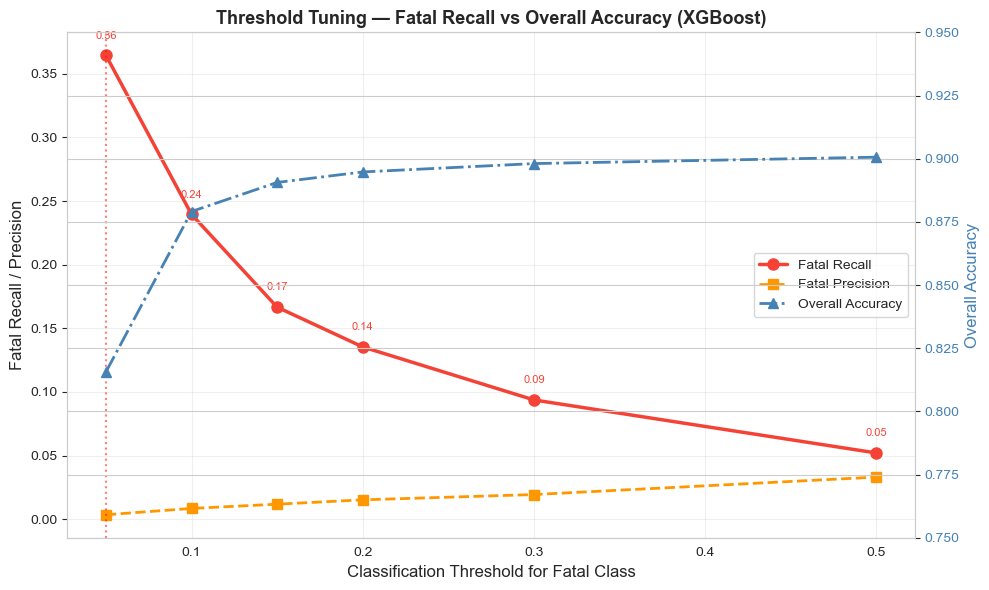

Recommended threshold: 0.05
  Fatal Recall: 0.0521 → 0.3646 (+31.2%)
  Accuracy:     0.9006 → 0.8156 (-8.5%)
  For road safety: higher recall is more important than accuracy


In [30]:
# ── Plot dynamically using computed values ──
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#F44336'
color2 = 'steelblue'
color3 = '#FF9800'

ax1.plot(thresholds, fatal_recalls,    'o-',  color=color1, linewidth=2.5, markersize=8, label='Fatal Recall')
ax1.plot(thresholds, fatal_precisions, 's--', color=color3, linewidth=2,   markersize=7, label='Fatal Precision')
ax1.set_xlabel('Classification Threshold for Fatal Class', fontsize=12)
ax1.set_ylabel('Fatal Recall / Precision', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(thresholds, accuracies, '^-.', color=color2, linewidth=2, markersize=7, label='Overall Accuracy')
ax2.set_ylabel('Overall Accuracy', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.75, 0.95)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

ax1.set_title('Threshold Tuning — Fatal Recall vs Overall Accuracy (XGBoost)',
              fontsize=13, fontweight='bold')
ax1.axvline(x=0.05, color='red', linestyle=':', alpha=0.5)
ax1.grid(alpha=0.3)

for i, t in enumerate(thresholds):
    ax1.annotate(f'{fatal_recalls[i]:.2f}',
                 (t, fatal_recalls[i]),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=8, color=color1)

plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_14_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Print recommendation based on actual computed values
best_threshold_idx = max(range(len(thresholds)),
                         key=lambda i: fatal_recalls[i])
best_threshold     = thresholds[best_threshold_idx]
best_recall        = fatal_recalls[best_threshold_idx]
default_recall     = fatal_recalls[thresholds.index(0.50)]
default_acc        = accuracies[thresholds.index(0.50)]
best_acc           = accuracies[best_threshold_idx]

print(f'Recommended threshold: {best_threshold}')
print(f'  Fatal Recall: {default_recall:.4f} → {best_recall:.4f} '
      f'(+{(best_recall-default_recall)*100:.1f}%)')
print(f'  Accuracy:     {default_acc:.4f} → {best_acc:.4f} '
      f'({(best_acc-default_acc)*100:.1f}%)')
print(f'  For road safety: higher recall is more important than accuracy')

In [31]:
# ══════════════════════════════════════════════════════
# Step 10 — Hyperparameter Tuning
# Using RandomizedSearchCV on XGBoost and Random Forest
# Testing 20 random combinations × 3-fold CV each
# ══════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# 3-fold stratified CV — fast but still reliable
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print('Hyperparameter tuning setup ready!')
print('Will tune: XGBoost and Random Forest')
print('Method: RandomizedSearchCV (20 combinations × 3 folds = 60 fits each)')

Hyperparameter tuning setup ready!
Will tune: XGBoost and Random Forest
Method: RandomizedSearchCV (20 combinations × 3 folds = 60 fits each)


In [32]:
# ── Tune XGBoost ──
xgb_param_grid = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(3, 10),
    'learning_rate':     uniform(0.01, 0.3),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_weight':  randint(1, 10)
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Tuning XGBoost...')
t = time.time()
xgb_search.fit(X_train_sm, y_train_sm)
print(f'Done in {(time.time()-t)/60:.1f} minutes')
print(f'\nBest XGBoost parameters:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:25s}: {round(v, 4) if isinstance(v, float) else v}')
print(f'\nBest CV F1 Macro: {xgb_search.best_score_:.4f}')

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done in 54.8 minutes

Best XGBoost parameters:
  colsample_bytree         : 0.8392
  learning_rate            : 0.2866
  max_depth                : 8
  min_child_weight         : 7
  n_estimators             : 351
  subsample                : 0.6181

Best CV F1 Macro: 0.9486


In [34]:
python# ── Tune Random Forest — memory optimized ──
# Using smaller sample to prevent memory overflow
# Random Forest on 1.2M rows with parallel jobs exceeds Windows memory limits

# Use a sample of training data (still representative)
sample_size = 200000  # 200k rows — much faster and memory safe
idx_sample  = np.random.choice(len(X_train_sm), sample_size, replace=False)
X_train_rf  = X_train_sm.iloc[idx_sample]
y_train_rf  = y_train_sm.iloc[idx_sample]

print(f'Using {sample_size:,} row sample for RF tuning (memory optimized)')

rf_param_grid = {
    'n_estimators':      randint(100, 300),
    'max_depth':         randint(5, 20),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'max_features':      ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=2       # ← limit to 2 cores instead of all cores
    ),
    param_distributions=rf_param_grid,
    n_iter=10,         # ← reduced from 20 to 10
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=1           # ← run searches sequentially to save memory
)

print('Tuning Random Forest...')
t = time.time()
rf_search.fit(X_train_rf, y_train_rf)
print(f'Done in {(time.time()-t)/60:.1f} minutes')
print(f'\nBest Random Forest parameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:25s}: {round(v, 4) if isinstance(v, float) else v}')
print(f'\nBest CV F1 Macro: {rf_search.best_score_:.4f}')

Using 200,000 row sample for RF tuning (memory optimized)
Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Done in 14.3 minutes

Best Random Forest parameters:
  max_depth                : 19
  max_features             : log2
  min_samples_leaf         : 6
  min_samples_split        : 4
  n_estimators             : 207

Best CV F1 Macro: 0.8397


In [35]:
# ── Compare tuned vs default ──
tuned_results = []

for name, search in [('XGBoost (Tuned)', xgb_search),
                     ('Random Forest (Tuned)', rf_search)]:
    y_pred = search.best_estimator_.predict(X_test)
    try:
        auc = roc_auc_score(
            y_test, search.best_estimator_.predict_proba(X_test),
            multi_class='ovr', average='weighted')
    except:
        auc = None

    report = classification_report(
        y_test, y_pred,
        target_names=['Minor','Major','Fatal'],
        output_dict=True, zero_division=0)

    tuned_results.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':  round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':     round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 Fatal':     round(report['Fatal']['f1-score'], 4),
        'Recall Fatal': round(report['Fatal']['recall'], 4),
        'ROC-AUC':      round(auc, 4) if auc else 'N/A'
    })

tuned_df = pd.DataFrame(tuned_results)

# Add default XGBoost and RF rows for comparison
default_rows = []
for name in ['XGBoost', 'Random Forest']:
    model  = trained_models[name]
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred,
                                   target_names=['Minor','Major','Fatal'],
                                   output_dict=True, zero_division=0)
    try:
        auc = roc_auc_score(y_test, model.predict_proba(X_test),
                            multi_class='ovr', average='weighted')
    except:
        auc = None
    default_rows.append({
        'Model':        f'{name} (Default)',
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':  round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':     round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 Fatal':     round(report['Fatal']['f1-score'], 4),
        'Recall Fatal': round(report['Fatal']['recall'], 4),
        'ROC-AUC':      round(auc, 4) if auc else 'N/A'
    })

comparison_df = pd.concat(
    [tuned_df, pd.DataFrame(default_rows)],
    ignore_index=True
).sort_values('F1 Macro', ascending=False)

print('Tuned vs Default Comparison:')
comparison_df

Tuned vs Default Comparison:


,Model,Accuracy,F1 Weighted,F1 Macro,F1 Fatal,Recall Fatal,ROC-AUC
2,XGBoost (Default),0.9002,0.8920,0.5193,0.0337,0.0521,0.7839
0,XGBoost (Tuned),0.8987,0.8886,0.5189,0.0496,0.0312,0.7929
3,Random Forest (Default),0.8972,0.8911,0.5148,0.0156,0.0208,0.7809
1,Random Forest (Tuned),0.8946,0.8888,0.5091,0.0072,0.0104,0.7822


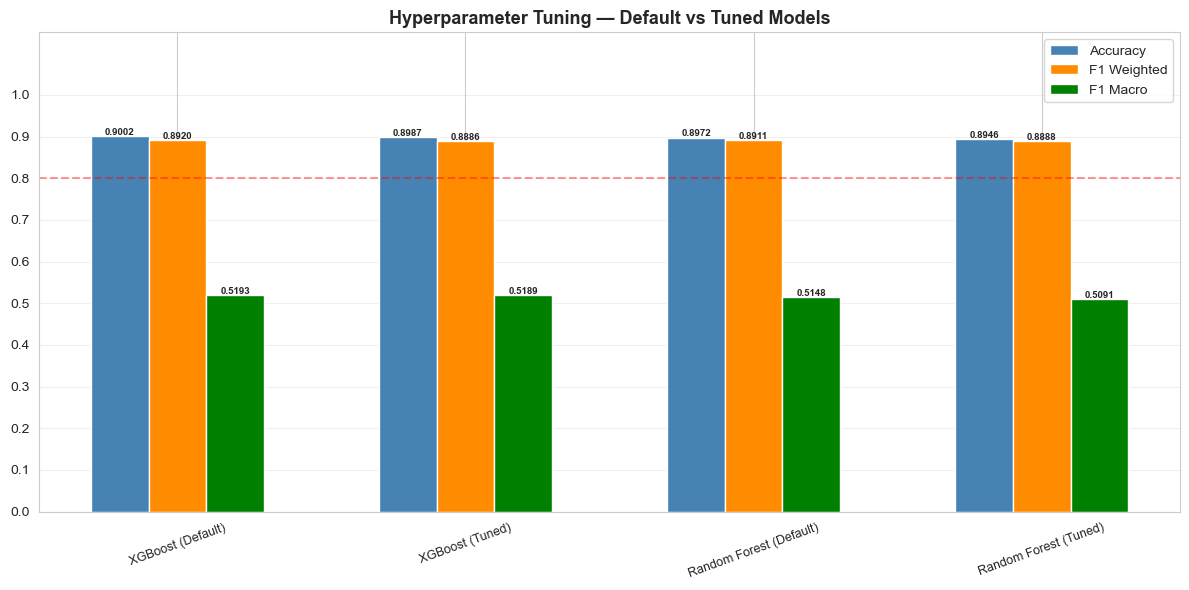

Best hyperparameters saved!
        Model         Parameter Best Value
      XGBoost  colsample_bytree     0.8392
      XGBoost     learning_rate     0.2866
      XGBoost         max_depth          8
      XGBoost  min_child_weight          7
      XGBoost      n_estimators        351
      XGBoost         subsample     0.6181
Random Forest         max_depth         19
Random Forest      max_features       log2
Random Forest  min_samples_leaf          6
Random Forest min_samples_split          4
Random Forest      n_estimators        207

Tuned models saved to trained_models.pkl


In [36]:
# ── Bar chart: Tuned vs Default ──
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
w = 0.2

ax.bar(x-w,  comparison_df['Accuracy'],    w, label='Accuracy',    color='steelblue',  edgecolor='white')
ax.bar(x,    comparison_df['F1 Weighted'], w, label='F1 Weighted', color='darkorange', edgecolor='white')
ax.bar(x+w,  comparison_df['F1 Macro'],   w, label='F1 Macro',    color='green',      edgecolor='white')

for bars in [ax.containers[0], ax.containers[1], ax.containers[2]]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003,
                f'{h:.4f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=20, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_yticks([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4)
ax.set_title('Hyperparameter Tuning — Default vs Tuned Models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_15_hyperparameter_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save best parameters to CSV
params_records = []
for name, search in [('XGBoost', xgb_search), ('Random Forest', rf_search)]:
    for param, value in search.best_params_.items():
        params_records.append({
            'Model':      name,
            'Parameter':  param,
            'Best Value': round(value, 4) if isinstance(value, float) else value
        })

params_df = pd.DataFrame(params_records)
params_df.to_csv(f'{MODELS_FOLDER}best_hyperparameters.csv', index=False)
print('Best hyperparameters saved!')
print(params_df.to_string(index=False))

# Save tuned models
trained_models['XGBoost (Tuned)']       = xgb_search.best_estimator_
trained_models['Random Forest (Tuned)'] = rf_search.best_estimator_
with open(f'{MODELS_FOLDER}trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)
print('\nTuned models saved to trained_models.pkl')

In [38]:
# ══════════════════════════════════════════════════════
# Step 11 — Cross-Validation
# 5-Fold Stratified Cross-Validation on best model (XGBoost)
# Gives mean ± std of performance — much more credible than single split
# ══════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, cross_validate

print('Running 5-Fold Stratified Cross-Validation on XGBoost...')
print('This uses the TUNED XGBoost if available, otherwise default.')
print()

# Use tuned model if available, otherwise default
cv_model = xgb_search.best_estimator_ if 'xgb_search' in dir() else trained_models['XGBoost']

# Use a sample for CV — full 677k × 5 folds is too slow
cv_sample_size = 100000
idx_cv = np.random.choice(len(X), cv_sample_size, replace=False)
X_cv   = X.iloc[idx_cv]
y_cv   = y.iloc[idx_cv]

print(f'Using {cv_sample_size:,} row stratified sample for CV')
print(f'Class distribution in sample:')
for k, v in y_cv.value_counts().sort_index().items():
    print(f'  {severity_labels[k]:8s}: {v:,} ({v/len(y_cv)*100:.1f}%)')

Running 5-Fold Stratified Cross-Validation on XGBoost...
This uses the TUNED XGBoost if available, otherwise default.

Using 100,000 row stratified sample for CV
Class distribution in sample:
  Minor   : 85,719 (85.7%)
  Major   : 14,182 (14.2%)
  Fatal   : 99 (0.1%)


In [39]:
# Run 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy':    'accuracy',
    'f1_weighted': 'f1_weighted',
    'f1_macro':    'f1_macro',
    'roc_auc':     'roc_auc_ovr_weighted'
}

print('\nRunning 5-fold CV (this may take 10-20 minutes)...')
t = time.time()

cv_results = cross_validate(
    cv_model,
    X_cv, y_cv,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print(f'Done in {(time.time()-t)/60:.1f} minutes')
print()
print('='*55)
print('  5-FOLD CROSS-VALIDATION RESULTS (XGBoost)')
print('='*55)
for metric, key in [('Accuracy',    'test_accuracy'),
                    ('F1 Weighted', 'test_f1_weighted'),
                    ('F1 Macro',    'test_f1_macro'),
                    ('ROC-AUC',     'test_roc_auc')]:
    scores = cv_results[key]
    print(f'  {metric:15s}: {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'               per fold: {[round(s,4) for s in scores]}')
print('='*55)


Running 5-fold CV (this may take 10-20 minutes)...
Done in 0.8 minutes

  5-FOLD CROSS-VALIDATION RESULTS (XGBoost)
  Accuracy       : 0.8931 ± 0.0011
               per fold: [np.float64(0.8921), np.float64(0.8926), np.float64(0.8921), np.float64(0.894), np.float64(0.8948)]
  F1 Weighted    : 0.8824 ± 0.0013
               per fold: [np.float64(0.8817), np.float64(0.882), np.float64(0.8807), np.float64(0.8832), np.float64(0.8846)]
  F1 Macro       : 0.4937 ± 0.0021
               per fold: [np.float64(0.4931), np.float64(0.4934), np.float64(0.4905), np.float64(0.4947), np.float64(0.4971)]
  ROC-AUC        : 0.7710 ± 0.0041
               per fold: [np.float64(0.7771), np.float64(0.7666), np.float64(0.7741), np.float64(0.7701), np.float64(0.7668)]


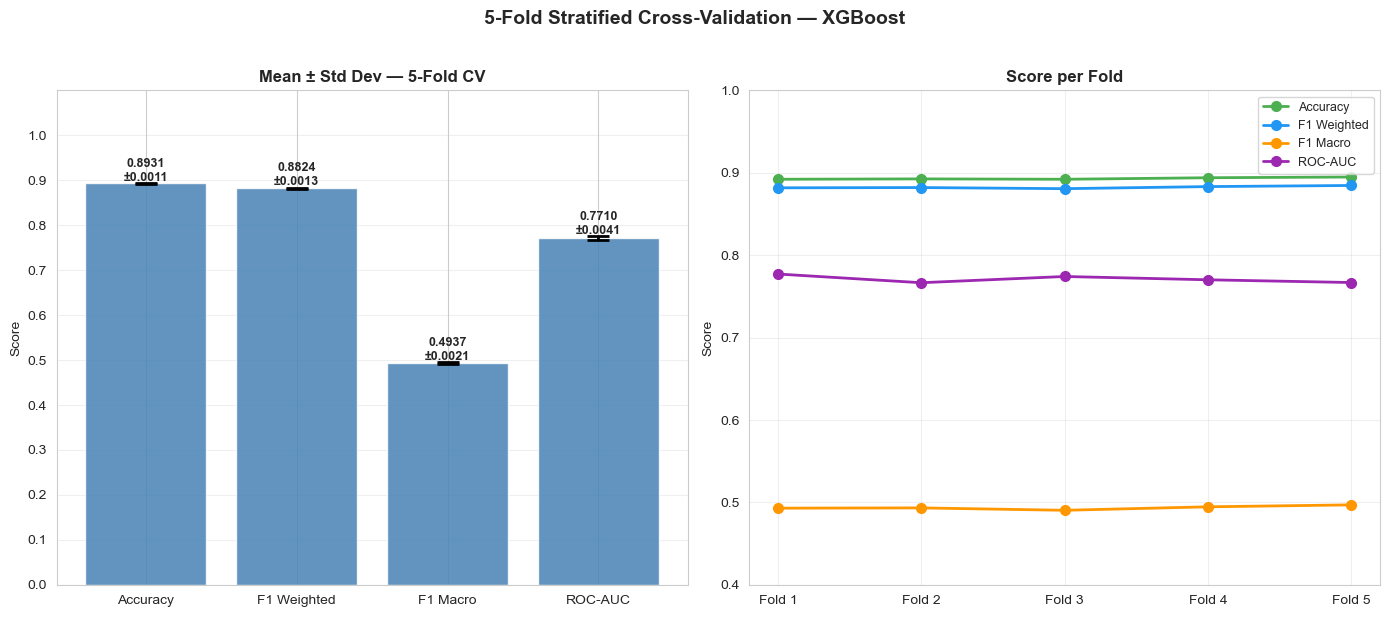

CV results saved to cv_results.csv
     Metric   Mean  Std Dev    Min    Max
   Accuracy 0.8931   0.0011 0.8921 0.8948
F1 Weighted 0.8824   0.0013 0.8807 0.8846
   F1 Macro 0.4937   0.0021 0.4905 0.4971
    ROC-AUC 0.7710   0.0041 0.7666 0.7771


In [40]:
# ── Plot CV results ──
metrics      = ['Accuracy', 'F1 Weighted', 'F1 Macro', 'ROC-AUC']
keys         = ['test_accuracy', 'test_f1_weighted', 'test_f1_macro', 'test_roc_auc']
means        = [cv_results[k].mean() for k in keys]
stds         = [cv_results[k].std()  for k in keys]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Mean scores with error bars
axes[0].bar(metrics, means, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].errorbar(metrics, means, yerr=stds, fmt='none',
                 color='black', capsize=8, capthick=2, linewidth=2)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.005, f'{m:.4f}\n±{s:.4f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_yticks([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
axes[0].set_title('Mean ± Std Dev — 5-Fold CV', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].grid(axis='y', alpha=0.3)

# Right: Per-fold scores
folds = [f'Fold {i+1}' for i in range(5)]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
for i, (key, metric, color) in enumerate(zip(keys, metrics, colors)):
    axes[1].plot(folds, cv_results[key], 'o-',
                 color=color, linewidth=2, markersize=7, label=metric)
axes[1].set_title('Score per Fold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.4, 1.0)
axes[1].grid(alpha=0.3)

plt.suptitle('5-Fold Stratified Cross-Validation — XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_16_cross_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save CV results
cv_summary = pd.DataFrame({
    'Metric':   metrics,
    'Mean':     [round(m, 4) for m in means],
    'Std Dev':  [round(s, 4) for s in stds],
    'Min':      [round(cv_results[k].min(), 4) for k in keys],
    'Max':      [round(cv_results[k].max(), 4) for k in keys]
})
cv_summary.to_csv(f'{MODELS_FOLDER}cv_results.csv', index=False)
print('CV results saved to cv_results.csv')
print(cv_summary.to_string(index=False))

In [37]:
print(f'Best model: {best_model_name}')
print(f'Saved to:   {MODELS_FOLDER}')
print('\n✅ Notebook 4 complete! Open Notebook 5 next.')

Best model: XGBoost
Saved to:   ../MRP - Final Sem/Models/

✅ Notebook 4 complete! Open Notebook 5 next.
